In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Objective function

$(x-3.14)^2 + (y-2.72)^2 + \sin(3x+1.41) + \sin(4y-1.73)$

In [2]:
def f(x,y):
    "Objective function"
    return (x-3.14)**2 + (y-2.72)**2 + np.sin(3*x+1.41) + np.sin(4*y-1.73)

 Compute and plot the function in 3D within [0,5]x[0,5]

In [3]:
x, y = np.array(np.meshgrid(np.linspace(0,5,100), np.linspace(0,5,100)))
z = f(x, y)

In [4]:
z.shape

(100, 100)

In [5]:
# Find the global minimum
# example of finding minimum from computed grid
x_min = x.ravel()[z.argmin()]
y_min = y.ravel()[z.argmin()]

In [6]:
# Hyper-parameter of the algorithm
c1 = c2 = 0.1
w = 0.8

In [7]:
# Create particles
n_particles = 20
np.random.seed(100)
X = np.random.rand(2, n_particles) * 5
V = np.random.randn(2, n_particles) * 0.1

In [8]:
# Initialize data
pbest = X
pbest_obj = f(X[0], X[1])
gbest = pbest[:, pbest_obj.argmin()]
gbest_obj = pbest_obj.min()

Dalam setiap langkah iterasi, kecepatan dan posisi partikel diperbarui menggunakan formula vektor:$$\mathbf{V}(t+1) = w \cdot \mathbf{V}(t) + c_1 r_1 (\mathbf{p}_{best} - \mathbf{X}(t)) + c_2 r_2 (\mathbf{g}_{best} - \mathbf{X}(t))$$

- Mekanisme Pergerakan:Inersia ($w$): Mempertahankan kecepatan lama (momentum).
- Komponen Kognitif ($c_1$): Partikel tertarik ke posisi terbaik yang pernah ia temukan sendiri ($p_{best}$).
- Komponen Sosial ($c_2$): Partikel tertarik ke posisi terbaik yang pernah ditemukan oleh kerumunan ($g_{best}$).

In [9]:
def update():
    "Function to do one iteration of particle swarm optimization"
    global V, X, pbest, pbest_obj, gbest, gbest_obj
    # Update params
    r1, r2 = np.random.rand(2)
    V = w * V + c1*r1*(pbest - X) + c2*r2*(gbest.reshape(-1,1)-X)
    X = X + V
    obj = f(X[0], X[1])
    pbest[:, (pbest_obj >= obj)] = X[:, (pbest_obj >= obj)]
    pbest_obj = np.array([pbest_obj, obj]).min(axis=0)
    gbest = pbest[:, pbest_obj.argmin()]
    gbest_obj = pbest_obj.min()

Setelah bergerak ke posisi baru $\mathbf{X}(t+1)$, nilai $f(x, y)$ dihitung.

- Jika posisi baru lebih baik dari $p_{best}$ lama, maka $p_{best}$ partikel diperbarui.
- Jika ada $p_{best}$ baru yang lebih baik dari $g_{best}$ saat ini, maka $g_{best}$ diperbarui (bintang hitam pindah posisi).

(0.0, 5.0)

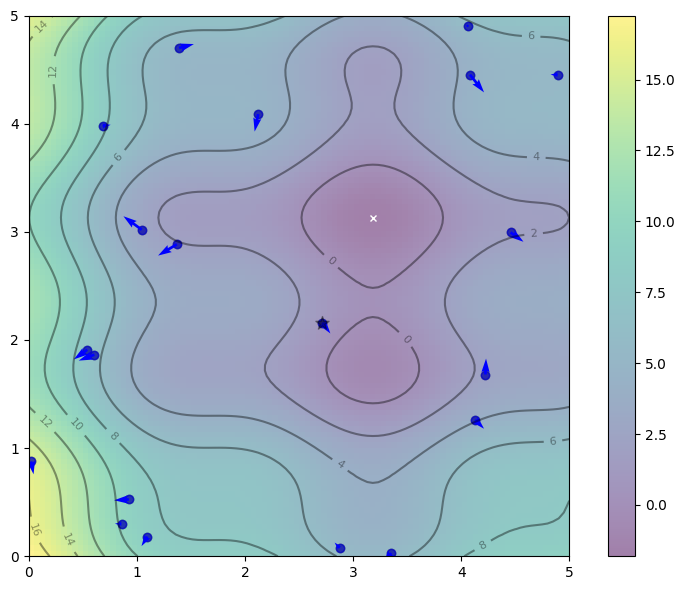

In [10]:
# Set up base figure: The contour map
fig, ax = plt.subplots(figsize=(8,6))
fig.set_tight_layout(True)
img = ax.imshow(z, extent=[0, 5, 0, 5], origin='lower', cmap='viridis', alpha=0.5)
fig.colorbar(img, ax=ax)
ax.plot([x_min], [y_min], marker='x', markersize=5, color="white")
contours = ax.contour(x, y, z, 10, colors='black', alpha=0.4)
ax.clabel(contours, inline=True, fontsize=8, fmt="%.0f")
pbest_plot = ax.scatter(pbest[0], pbest[1], marker='o', color='black', alpha=0.5)
p_plot = ax.scatter(X[0], X[1], marker='o', color='blue', alpha=0.5)
p_arrow = ax.quiver(X[0], X[1], V[0], V[1], color='blue', width=0.005, angles='xy', scale_units='xy', scale=1)
gbest_plot = plt.scatter([gbest[0]], [gbest[1]], marker='*', s=100, color='black', alpha=0.4)
ax.set_xlim([0,5])
ax.set_ylim([0,5])

In [11]:
def animate(i):
    "Steps of PSO: algorithm update and show in plot"
    title = 'Iteration {:02d}'.format(i)
    # Update params
    update()
    # Set picture
    ax.set_title(title)
    pbest_plot.set_offsets(pbest.T)
    p_plot.set_offsets(X.T)
    p_arrow.set_offsets(X.T)
    p_arrow.set_UVC(V[0], V[1])
    gbest_plot.set_offsets(gbest.reshape(1,-1))
    return ax, pbest_plot, p_plot, p_arrow, gbest_plot

In [12]:
anim = FuncAnimation(fig, animate, frames=list(range(1,50)), interval=500, blit=False, repeat=True)
anim.save("PSO.gif", dpi=120, writer="imagemagick")

MovieWriter imagemagick unavailable; using Pillow instead.


![result](PSO.gif)

In [13]:
print("PSO found best solution at f({})={}".format(gbest, gbest_obj))
print("Global optimal at f({})={}".format([x_min,y_min], f(x_min,y_min)))

PSO found best solution at f([3.18541756 3.12972478])=-1.8083516042208303
Global optimal at f([3.1818181818181817, 3.131313131313131])=-1.8082706615747688
